In [1]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams["font.size"] = 14

from sk_utils import Utils as u
from sk_models import RetinalGanglionCellMosaic as RGCmodel
from sk_models import Retina

In [2]:
u.check_gpus()

GPUs present?	True	1
Device 0: NVIDIA RTX 6000 Ada Generation


In [3]:
all_params = u.read_params("params.yaml")
on_parasol_params = all_params["ON_Parasol"]
off_parasol_params = all_params["OFF_Parasol"]
on_midget_params = all_params["ON_Midget"]
off_midget_params = all_params["OFF_Midget"]
video_params = all_params["video_parameters"]

30.000011135861595


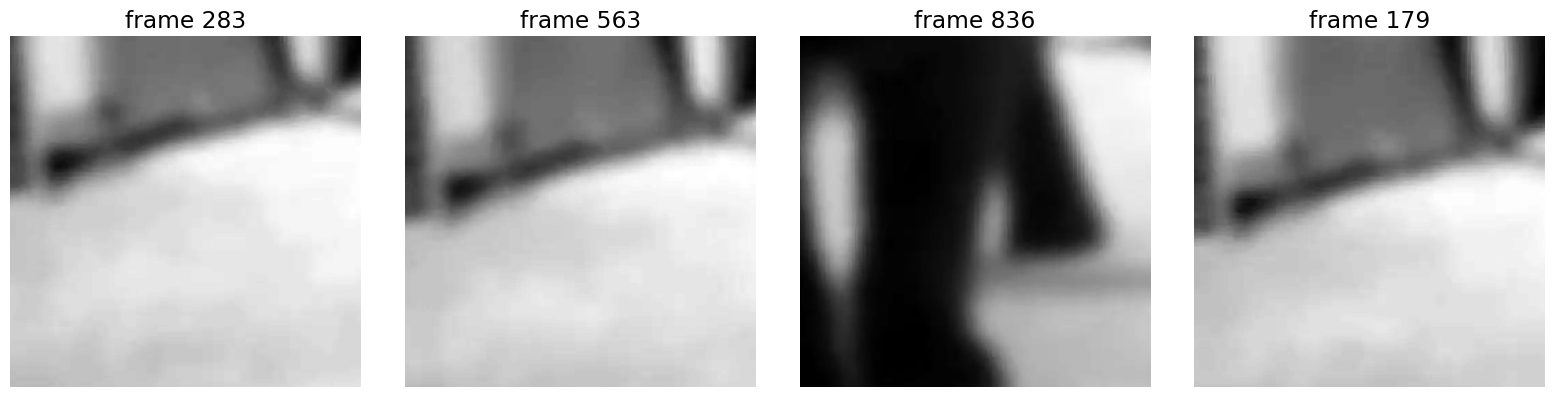

In [4]:
video, fps = u.read_video("lnp_naturalmovies/Video_2.mp4")
print(fps)

# let's crop (512, 512) patches
video_patch = np.array([f[500:500+video_params["frame_shape"][0], 500:500+video_params["frame_shape"][1]] for f in video])

# just visualize a few frames
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
frames = np.random.uniform(0, len(video_patch), 4).astype(np.uint32)

for i,f in enumerate(frames):
    ax[i].imshow(video_patch[f], cmap="gray")
    ax[i].axis("off")
    ax[i].set_title(f"frame {f}")

fig.set_tight_layout(True)
plt.show()

## Mosaic

Testing each RGC Mosaic independently

In [5]:
models = {
    "ON parasol": RGCmodel(model_parameters=on_parasol_params, video_parameters=video_params),
    "OFF parasol": RGCmodel(model_parameters=off_parasol_params, video_parameters=video_params),
    "ON midget": RGCmodel(model_parameters=on_midget_params, video_parameters=video_params),
    "OFF midget": RGCmodel(model_parameters=off_midget_params, video_parameters=video_params)
}

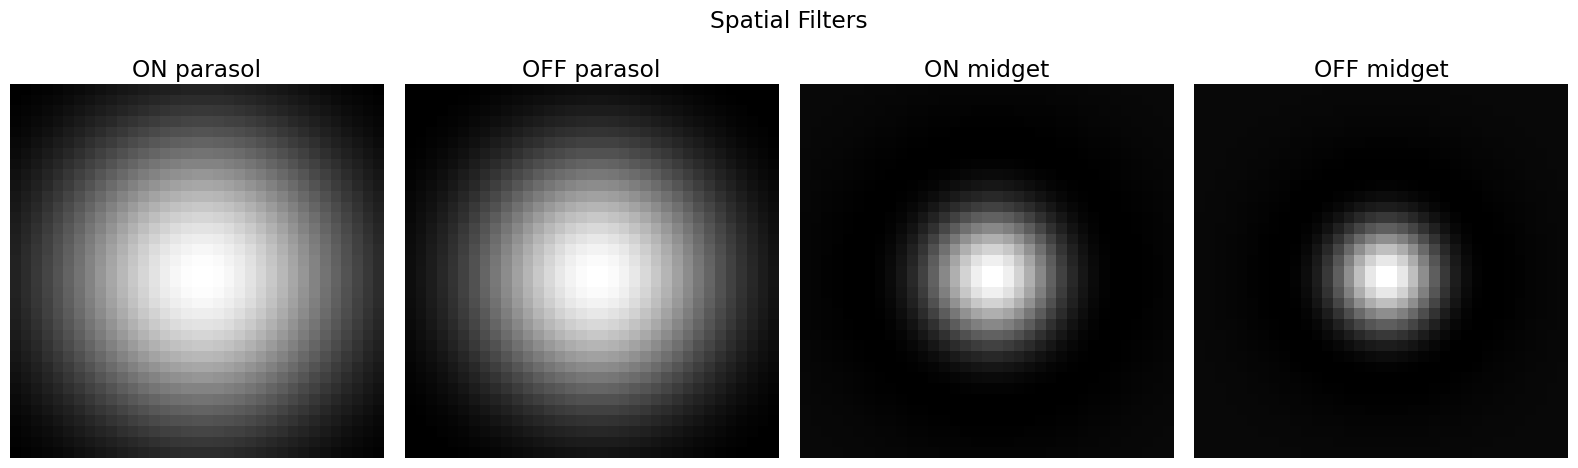

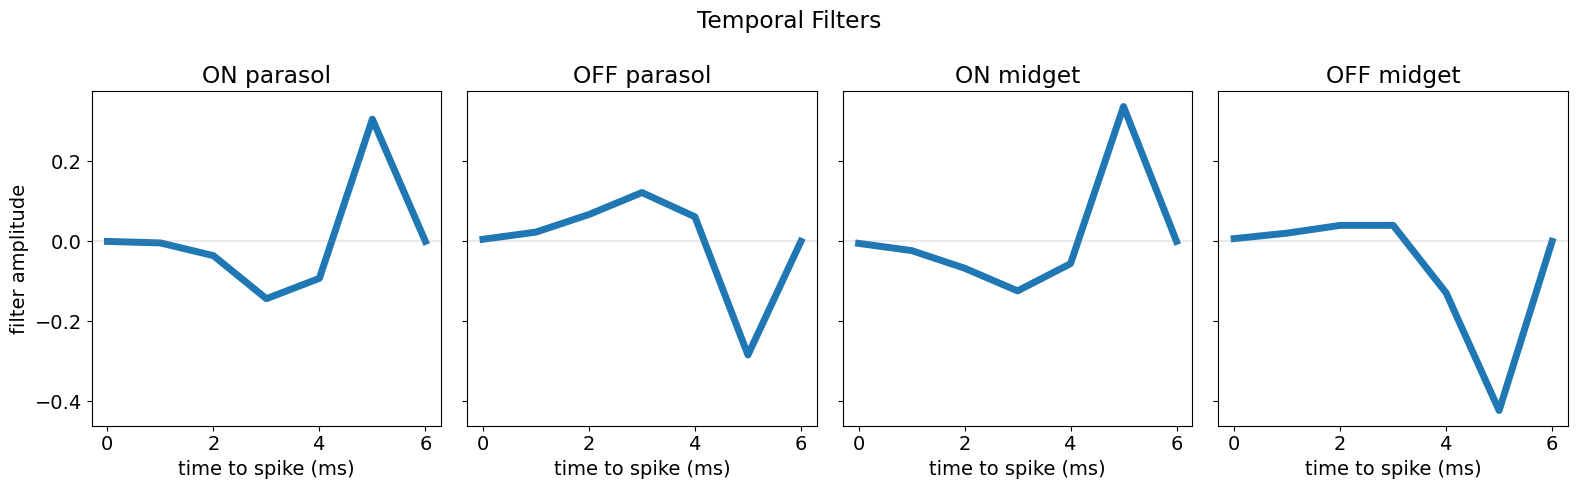

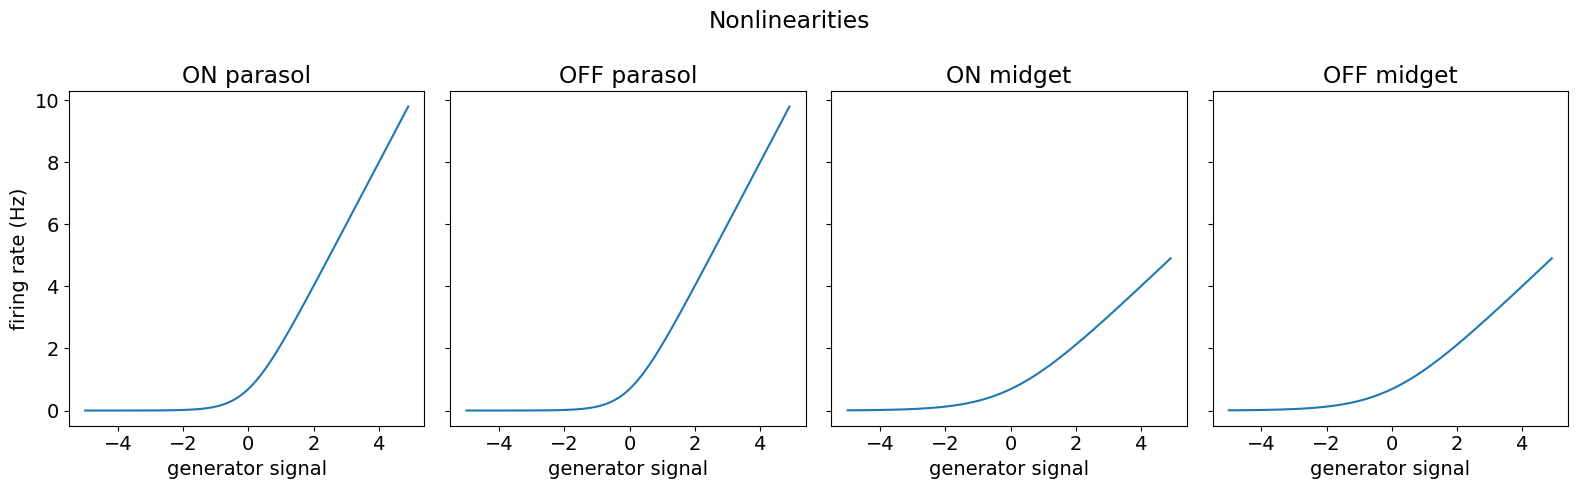

In [6]:
# plot the spatial filters
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

for i, (celltype,model) in enumerate(models.items()):

    ax[i].imshow(model.spatial_filter, cmap="gray")
    ax[i].set_title(celltype)
    ax[i].axis("off")

fig.suptitle("Spatial Filters")

fig.set_tight_layout(True)
plt.show()

# plot the temporal filters
fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)

for i, (celltype,model) in enumerate(models.items()):

    ax[i].plot(model.temporal_filter, lw=5)
    ax[i].axhline(y=0, c="gray", lw=0.25)
    ax[i].set_title(celltype)
    ax[i].set_xlabel("time to spike (ms)")

fig.suptitle("Temporal Filters")
ax[0].set_ylabel("filter amplitude")

fig.set_tight_layout(True)
plt.show()

# plot the nonlinearities
fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharex=True, sharey=True)

for i, (celltype,model) in enumerate(models.items()):

    ax[i].plot(np.arange(-5, 5, 0.1), model.nonlinearity(torch.arange(-5, 5, 0.1)))
    ax[i].set_title(celltype)
    ax[i].set_xlabel("generator signal")

fig.suptitle("Nonlinearities")
ax[0].set_ylabel("firing rate (Hz)")

fig.set_tight_layout(True)
plt.show()

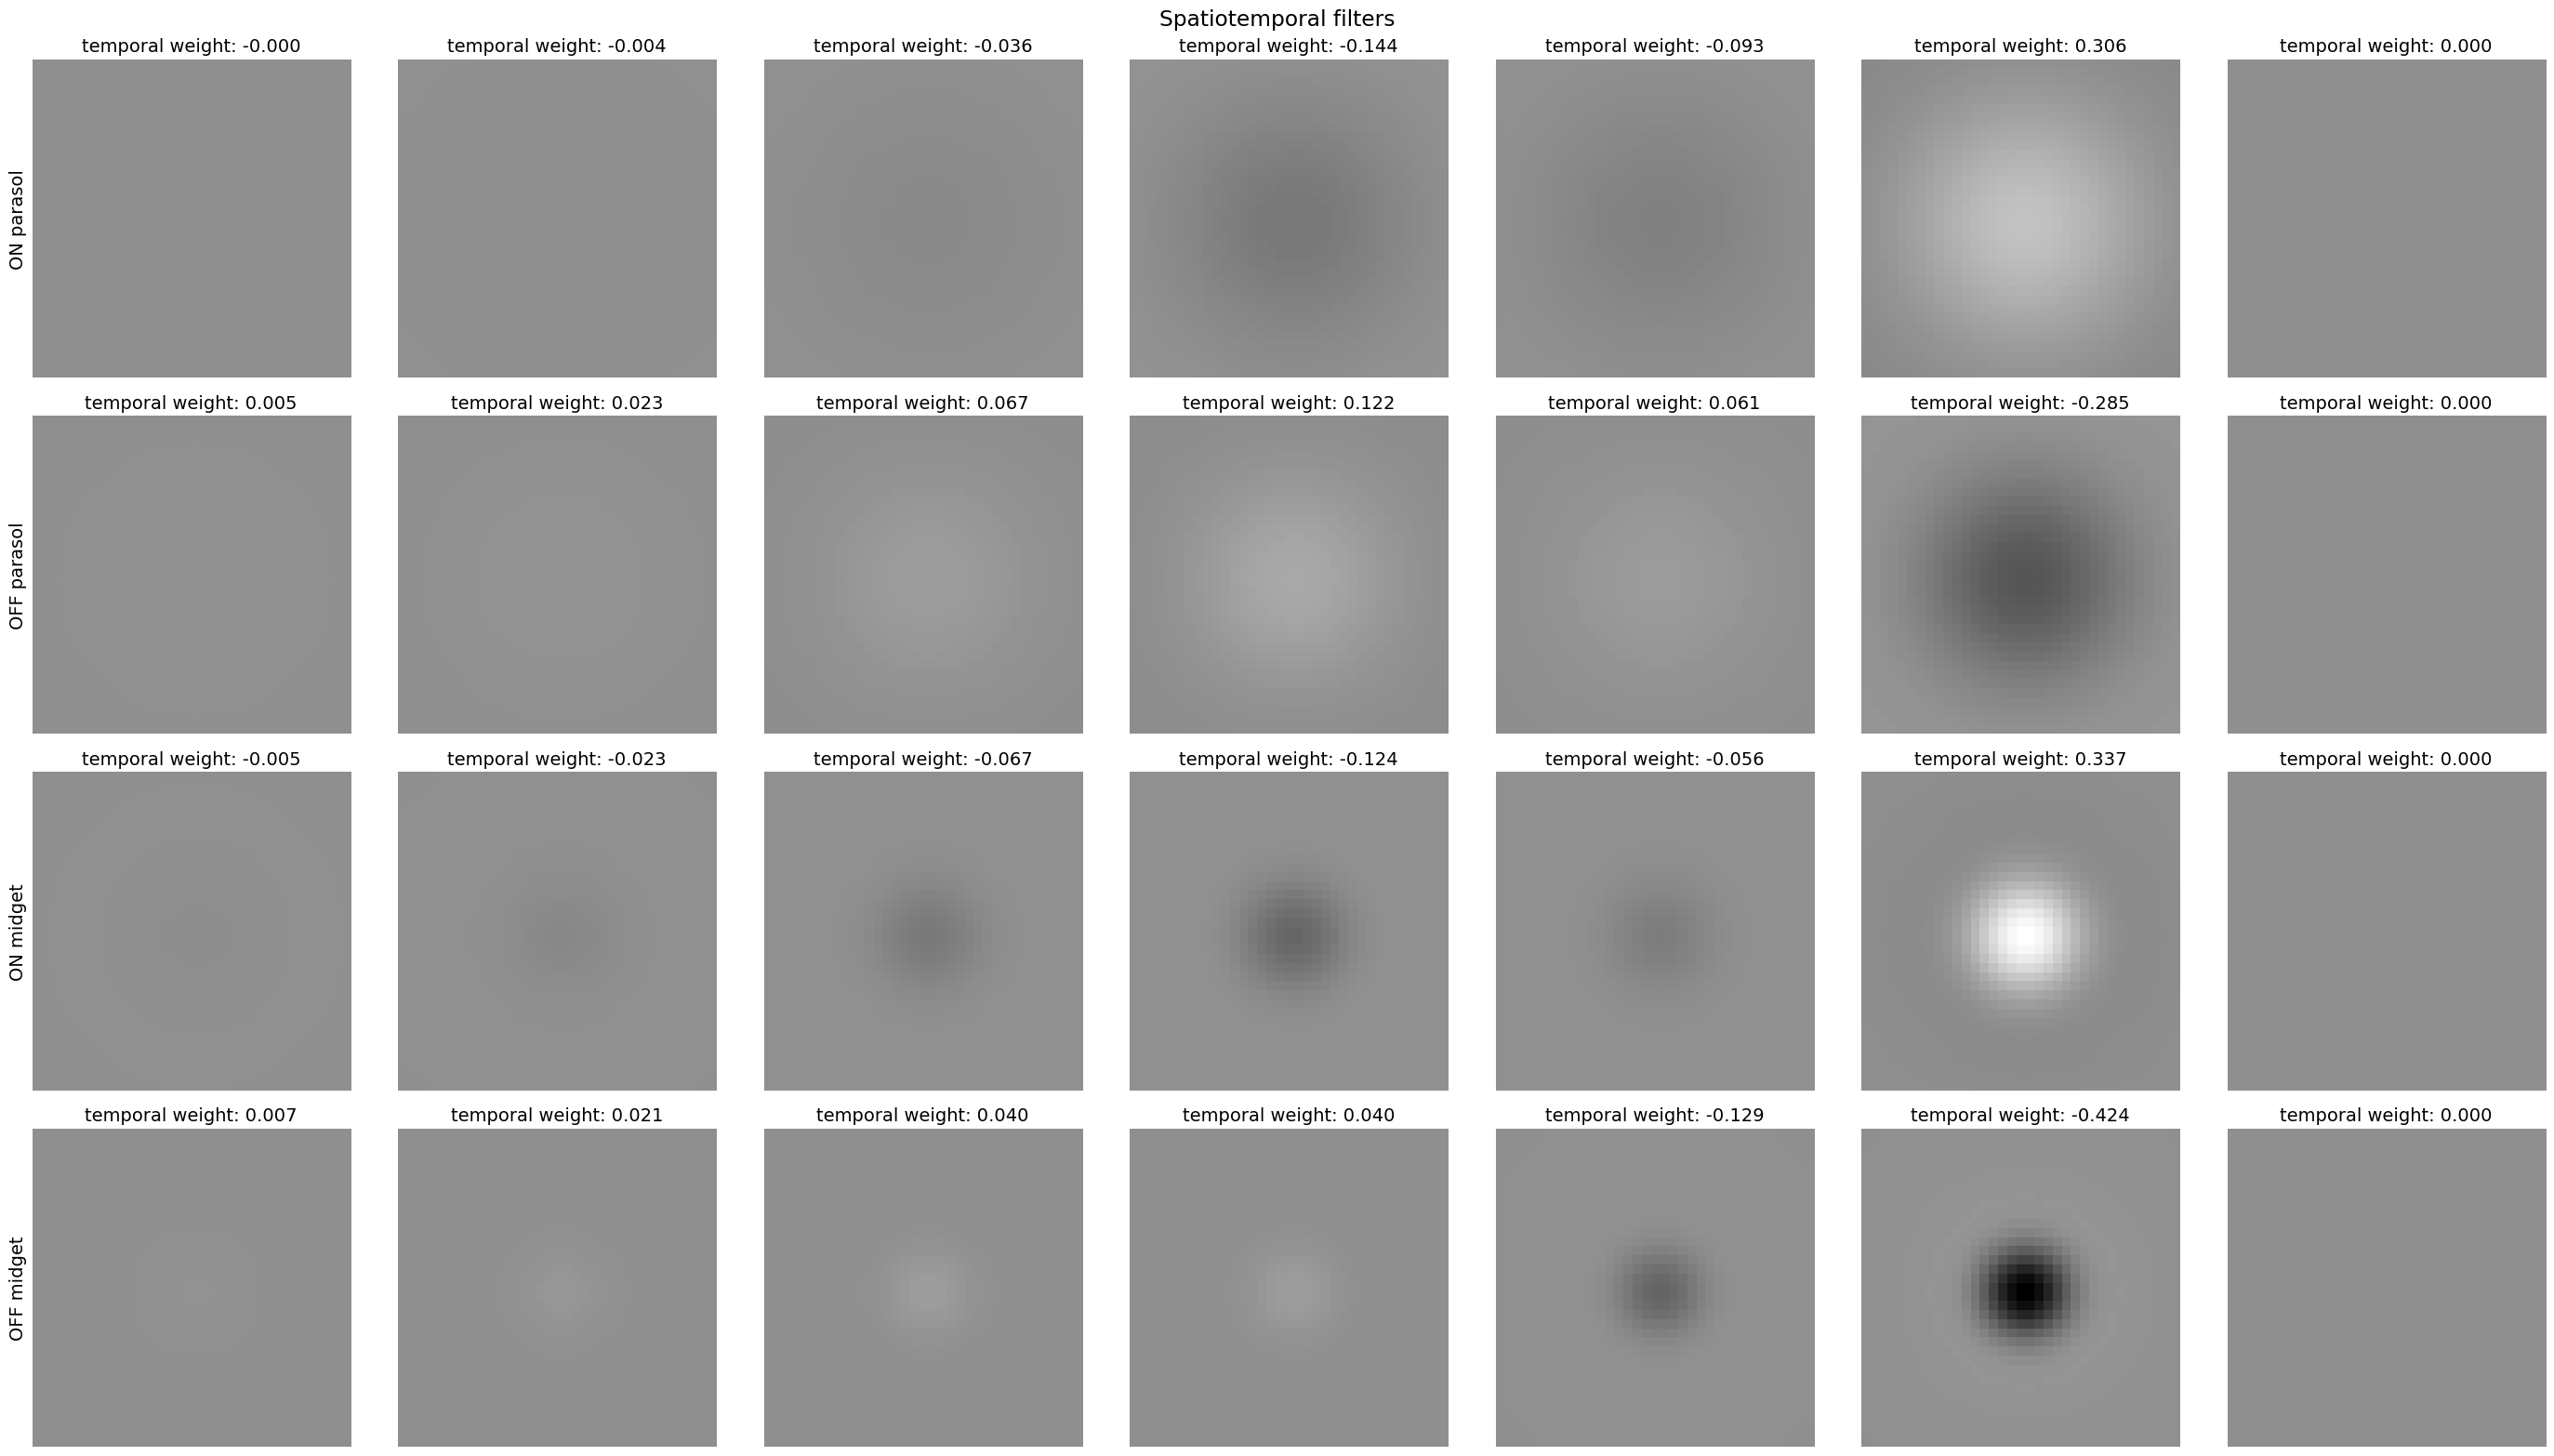

In [7]:
# combine the spatial and temporal filters to show what the combined information encodes
fig, ax = plt.subplots(4, 7, figsize=(28, 16))

# compute min and max for comparisons
min_v, max_v = 0, 0
for celltype,model in models.items():
    if model.spatiotemporal_filter.min() < min_v:
        min_v = model.spatiotemporal_filter.min()
    if model.spatiotemporal_filter.max() > max_v:
        max_v = model.spatiotemporal_filter.max()

for i,(celltype,model) in enumerate(models.items()):

    for j,t in enumerate(model.temporal_filter):
        ax[i][j].imshow(model.spatiotemporal_filter[j], cmap="gray", vmin=min_v, vmax=max_v)
        ax[i][j].set_title(f"temporal weight: {t:.3f}", fontsize=14)

        # turning off the border
        ax[i][j].set_xticks([])
        ax[i][j].set_yticks([])
        ax[i][j].set_frame_on(False)

    ax[i][0].set_ylabel(celltype)

fig.suptitle("Spatiotemporal filters")
fig.set_tight_layout(True)
plt.show()

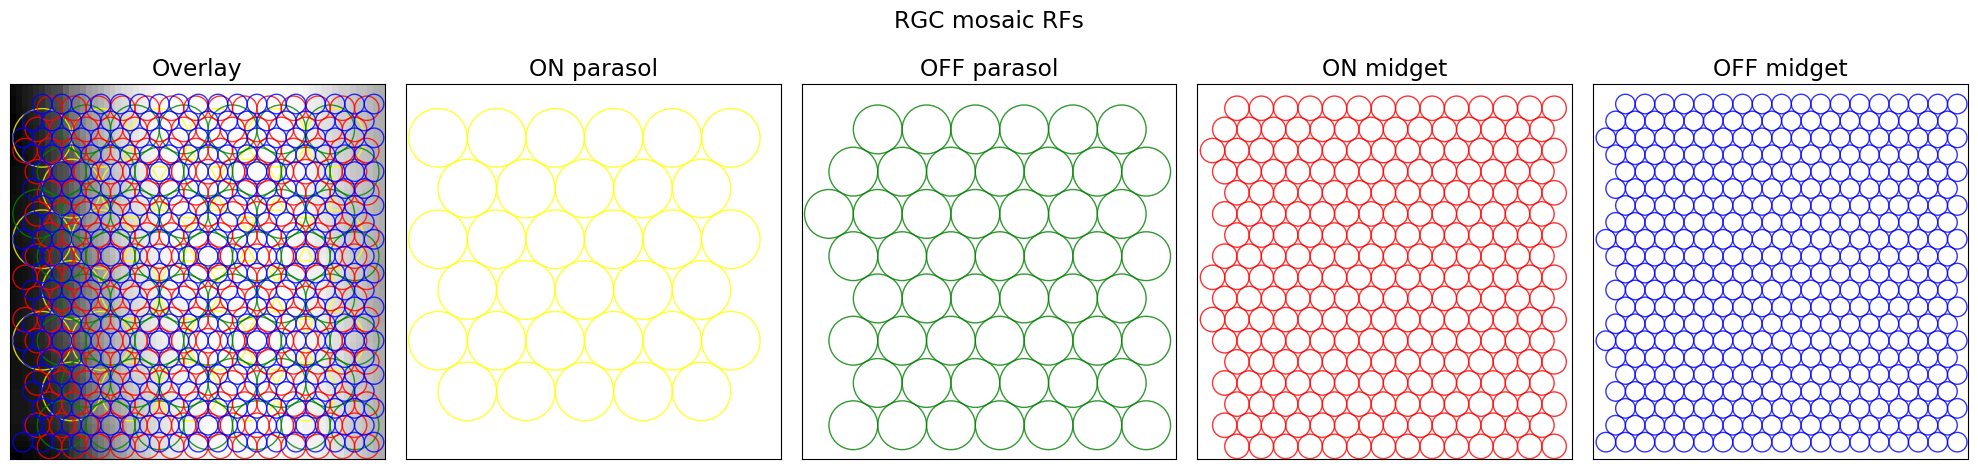

In [8]:
# now let's mosaic these, so we can see the multiple cell types
colors = ["blue", "red", "green", "yellow"]
colors.reverse()

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
ax[0].imshow(video_patch[182], cmap="gray")

# plot on parasol RFs
for i,(celltype,model) in enumerate(models.items()):
    
    for x,y in model.mosaic:

        # make 2 mosaics bc of plt limitations
        joint_circle = patches.Circle((x, y), model.m_params["spatial"]["center_size"]/2, 
                                        linewidth=1, edgecolor=colors[i], 
                                        facecolor='none', alpha=0.8)
        ind_circle = patches.Circle((x, y), model.m_params["spatial"]["center_size"]/2, 
                                        linewidth=1, edgecolor=colors[i], 
                                        facecolor='none', alpha=0.8)

        # plot jointly
        ax[0].add_patch(joint_circle)

        # also add each cell type to an independent mosaic so we can observe them
        ax[i+1].imshow(np.ones(shape=(64,64)), cmap="gray", vmin=0, vmax=1)
        ax[i+1].add_patch(ind_circle)
        ax[i+1].set_title(celltype)
    
ax[0].set_title("Overlay")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

fig.suptitle("RGC mosaic RFs")
fig.set_tight_layout(True)
plt.show()

In [9]:
generator_signals = {}
firing_rates = {}
times = {}
counts = {}

for celltype,model in models.items():
    generator_signals[celltype], firing_rates[celltype] = model.forward(video_patch)
    times[celltype], counts[celltype] = model.spikes(firing_rates[celltype])

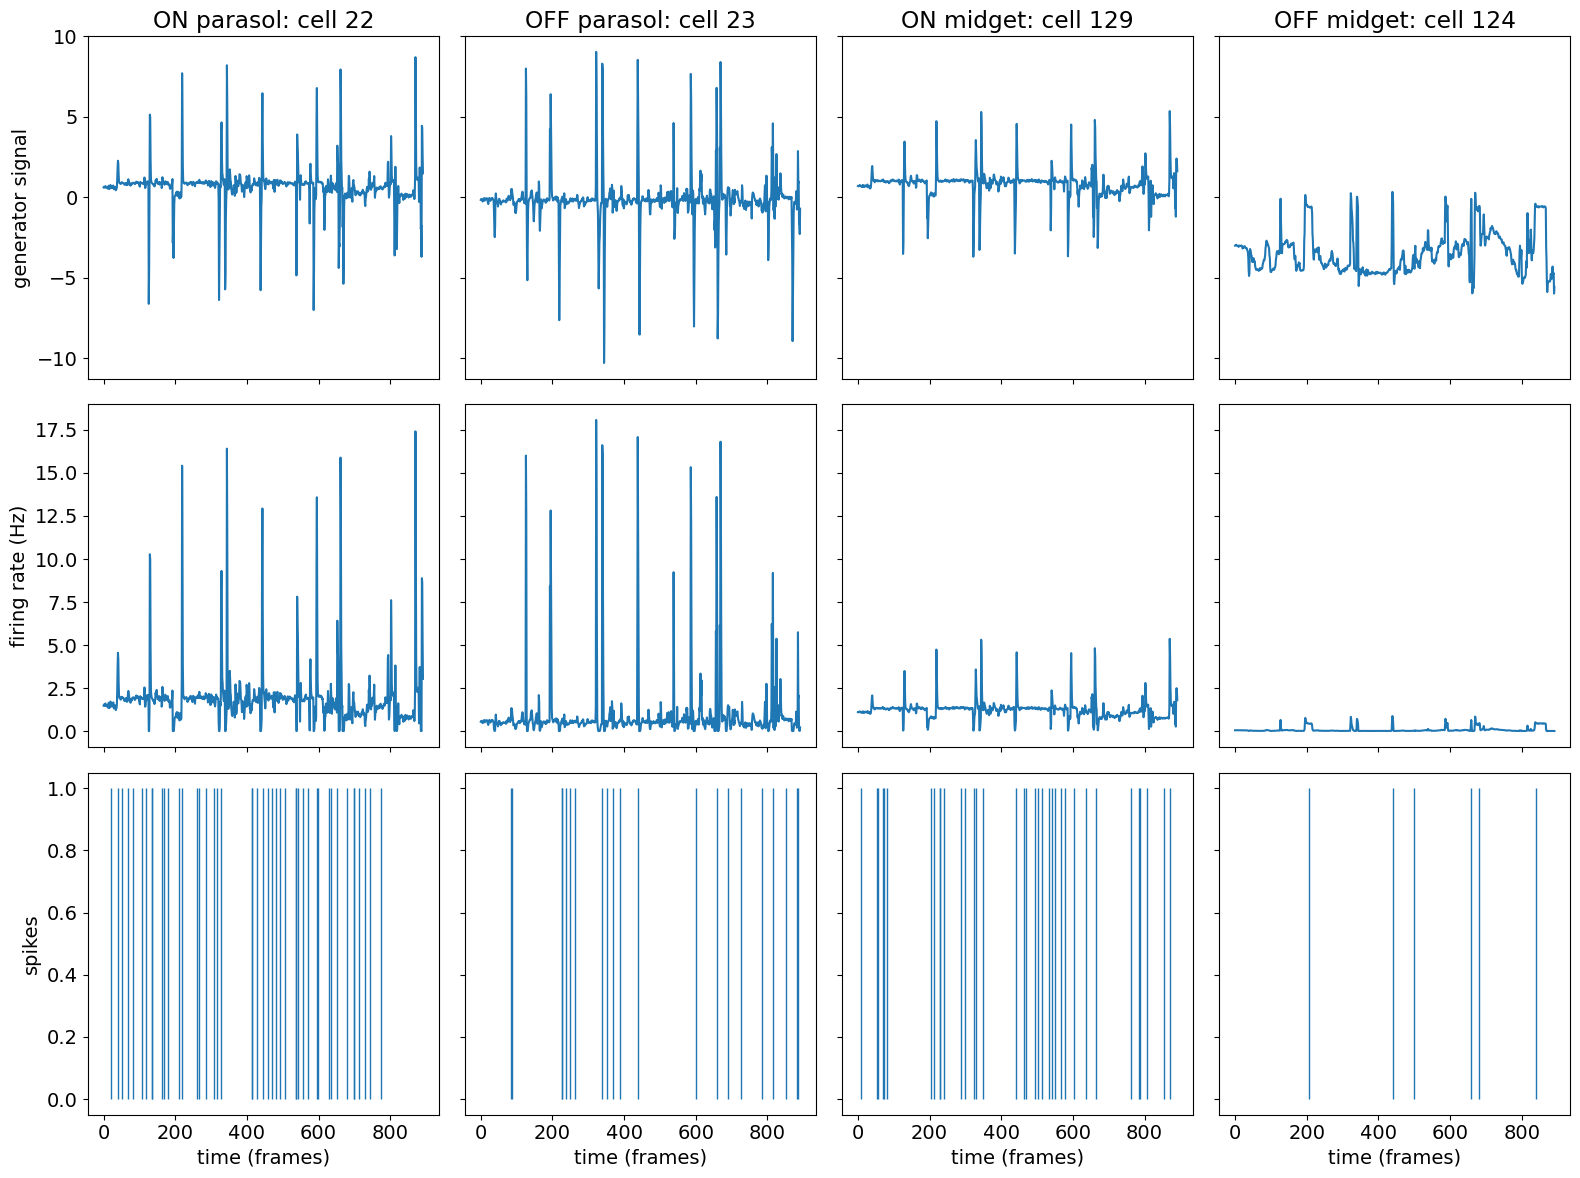

In [10]:
# plot the responses from one cell from each celltype group
fig, ax = plt.subplots(3, 4, figsize=(16, 12), sharex=True, sharey="row")

for j,celltype in enumerate(models.keys()):
    rand_cell = np.random.randint(0, generator_signals[celltype].shape[0])

    ax[0][j].plot(generator_signals[celltype][rand_cell])
    ax[1][j].plot(firing_rates[celltype][rand_cell])
    ax[2][j].vlines(np.arange(len(generator_signals[celltype][rand_cell]))[counts[celltype][rand_cell] == 1], 0, 1, lw=1)

    # set our axes titles/labels
    if j == 0:
        ax[0][j].set_ylabel("generator signal")
        ax[1][j].set_ylabel("firing rate (Hz)")
        ax[2][j].set_ylabel("spikes")
    ax[2][j].set_xlabel("time (frames)")

    # set titles
    ax[0][j].set_title(f"{celltype}: cell {rand_cell}")

fig.set_tight_layout(True)
plt.show()

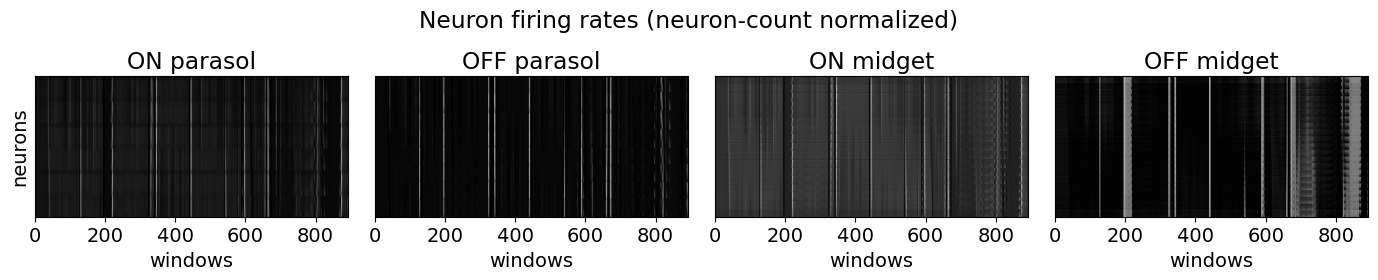

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(14, 2.5))

for i,celltype in enumerate(models.keys()):
    ax[i].imshow(firing_rates[celltype].numpy(), cmap="gray", aspect=400/models[celltype].n_cells)
    ax[i].set_title(celltype)
    ax[i].set_xlabel("windows")
    ax[i].set_yticks([])
    ax[0].set_ylabel("neurons")

fig.suptitle("Neuron firing rates (neuron-count normalized)")
fig.set_tight_layout(True)
plt.show()

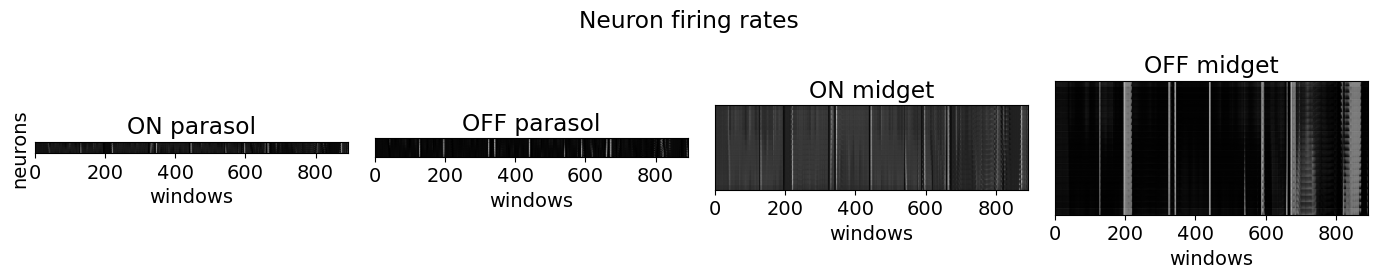

In [12]:
fig, ax = plt.subplots(1, 4, figsize=(14, 2.5))

for i,celltype in enumerate(models.keys()):
    ax[i].imshow(firing_rates[celltype].numpy(), cmap="gray")
    ax[i].set_title(celltype)
    ax[i].set_xlabel("windows")
    ax[i].set_yticks([])
    ax[0].set_ylabel("neurons")

fig.suptitle("Neuron firing rates")
fig.set_tight_layout(True)
plt.show()

## Retina

Let's test my retina class to make sure it produces outputs we expect

In [5]:
retina = Retina(model_parameters=all_params, video_parameters=video_params)

In [6]:
activations = retina.forward(video_patch)

torch.Size([700, 892])
torch.Size([1008, 892])
torch.Size([4216, 892])
torch.Size([6663, 892])


In [7]:
activations.shape

torch.Size([4, 6663, 892])

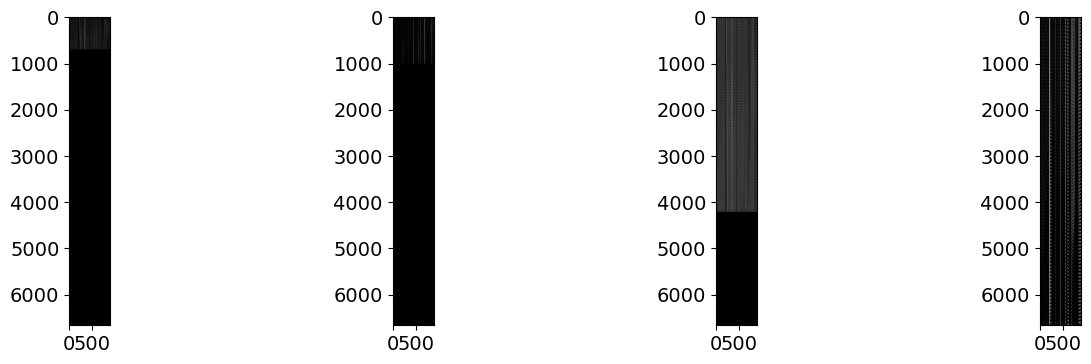

In [8]:
# let's double check that we have some zeroed out cells
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i,c_act in enumerate(activations):
    ax[i].imshow(c_act, cmap="gray")

plt.show()

In [ ]:
# now, if i take a single time slice, t, we should be able to use
# that image to recreate the image patch at time t
t = 136

